In [1]:
import numpy as np
import glob
from scipy import integrate, interpolate
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as colors
from matplotlib import cm
from matplotlib.colors import ListedColormap
from scipy.integrate import ode
from scipy.integrate import solve_ivp
from scipy import optimize
import matplotlib.font_manager

In [2]:
matplotlib.rcParams['xtick.direction'] = 'in'
matplotlib.rcParams['ytick.direction'] = 'in'
matplotlib.rcParams['xtick.top'] = True
matplotlib.rcParams['ytick.right'] = True
matplotlib.rcParams['xtick.minor.visible'] = True
matplotlib.rcParams['ytick.minor.visible'] = True
matplotlib.rcParams['lines.dash_capstyle'] = "round"
matplotlib.rcParams['lines.solid_capstyle'] = "round"
matplotlib.rcParams['legend.handletextpad'] = 0.4
matplotlib.rcParams['axes.linewidth'] = 0.6
matplotlib.rcParams['ytick.major.width'] = 0.6
matplotlib.rcParams['xtick.major.width'] = 0.6
matplotlib.rcParams['ytick.minor.width'] = 0.45
matplotlib.rcParams['xtick.minor.width'] = 0.45
matplotlib.rcParams['ytick.major.size'] = 2.75
matplotlib.rcParams['xtick.major.size'] = 2.75
matplotlib.rcParams['ytick.minor.size'] = 1.75
matplotlib.rcParams['xtick.minor.size'] = 1.75
matplotlib.rcParams['legend.handlelength'] = 2
matplotlib.rcParams["figure.dpi"] = 200

In [3]:
gamma   = 5/3.
kb      = 1.3806488e-16
mp      = 1.67373522381e-24
km      = 1e5
s       = 1
yr      = 3.1536e7
Myr     = 3.1536e13
Gyr     = 3.1536e16
pc      = 3.086e18
kpc     = 1.0e3 * pc
Mpc     = 1.0e6 * pc
H0      = 67.74*km/s/Mpc
Om      = 0.3075
OL      = 1 - Om
G       = 6.673e-8
Msun    = 2.e33
fb      = 0.158
keV     = 1.60218e-9

mu = 0.62
metallicity = 10**-0.5
muH = 1/0.75
redshift = 0.0

In [4]:
data = np.load("Lambda_tab.npz")
Lambda_tab = data['Lambda_tab']
redshifts  = data['redshifts']
Zs         = data['Zs']
log_Tbins  = data['log_Tbins']
log_nHbins = data['log_nHbins']
Lambda     = interpolate.RegularGridInterpolator((log_nHbins,log_Tbins,Zs,redshifts), Lambda_tab, bounds_error=False, fill_value=1e-30)

metallicity = 1.
redshift = 0.
Ps = np.logspace(-8,10,100)
rhos = np.logspace(-10,5,101)*mu*mp
Lambda_P_rho_tab = np.zeros((len(Ps),len(rhos)))
for i in range(len(Ps)):
    for j in range(len(rhos)):
        rho = rhos[j]
        T = Ps[i] * (mu*mp/rho)
        if rho > 1*muH*mp:
            rho = 1.*muH*mp
        elif rho < 1e-8*muH*mp:
            rho = 1e-8*muH*mp
        if T > 10**8.98:
            T = 10**8.98
        elif T < 1e2:
            T = 1e2
        try:
            Lambda_P_rho_tab[i,j] = Lambda((np.log10(rho/(muH*mp)),np.log10(T), metallicity, redshift))
        except:
            Lambda_P_rho_tab[i,j] = 1e-30
    if i%10 == 0:
        print(i)

Lambda_P_rho = interpolate.RegularGridInterpolator((Ps*kb, rhos), Lambda_P_rho_tab, bounds_error=False, fill_value=0.)


Lambda_z0  = interpolate.RegularGridInterpolator((log_nHbins,log_Tbins,Zs), Lambda_tab[...,0], bounds_error=False, fill_value=-1e-30)

def tcool_P(T,P, metallicity):
    T = np.where(T>10**8.98, 10**8.98, T)
    T = np.where(T<10**2, 10**2, T)
    nH_actual = P/T*(mu/muH)
    nH = np.where(nH_actual>1, 1, nH_actual)
    nH = np.where(nH<10**-8, 10**-8, nH)
    return 1.5 * (muH/mu)**2 * kb * T / ( nH_actual * Lambda_z0((np.log10(nH),np.log10(T), metallicity))) # I think the (muH/mu)**2 factor is wrong here --- double check!

def Lambda_z0_P(T,P, metallicity):
    nH = P/T*(mu/muH)
    if nH > 0.9:
        nH = 0.9
    return Lambda_z0((np.log10(nH),np.log10(T), metallicity))
Lambda_z0_P  = np.vectorize(Lambda_z0_P)


T = np.logspace(3.5,6.5,1000)
T_tcool_min_array = np.zeros((len(Ps),len(Zs)))
tcool_min_array = np.zeros((len(Ps),len(Zs)))
for i,P in enumerate(Ps):
    if P > 10**4.2:
        continue
    for j,Z in enumerate(Zs):
        tcools = tcool_P(T, P, Z)
        T_tcool_min_array[i,j] = T[np.where(tcools == np.min(tcools[np.where(tcools>0)]))[0][0]]
        tcool_min_array[i,j] = np.min(tcools[tcools>0])

for i in np.where(Ps > 10**4.2)[0]:
    T_tcool_min_array[i] = T_tcool_min_array[np.where(Ps > 10**4.2)[0][0]-1]
    tcool_min_array[i] = tcool_min_array[np.where(Ps > 10**4.2)[0][0]-1] * (Ps[i]/ Ps[np.where(Ps > 10**4.2)[0][0]-1])**-1

T_tcool_min_P  = interpolate.RegularGridInterpolator((Ps,Zs), T_tcool_min_array, bounds_error=False, fill_value=None )
tcool_min_P  = interpolate.RegularGridInterpolator((Ps,Zs), tcool_min_array, bounds_error=False, fill_value=None )


0
10
20
30
40
50
60
70
80
90


In [91]:
def calculate_moments(eta_M, eta_M_cold_tot, log_M_cloud0, galaxy_properties):
    try:
        SFR = galaxy_properties[0]
        r0  = galaxy_properties[1]
        v_circ0 = galaxy_properties[2]
        Z_cloud_initial = galaxy_properties[3]
        eta_E = galaxy_properties[4]


        ### METALLICITY
        Z_solar = 0.02

        # feedback and SF props
        E_SN        = 1e51
        mstar       = 100*Msun
        M_cloud_min = 1e-2*Msun

        ## model choices
        CoolingAreaChiPower         =  0.5
        ColdTurbulenceChiPower      = -0.5
        TurbulentVelocityChiPower   =  0.0
        geometric_factor            = 1.0
        Mdot_coefficient            = 1.0/3.0
        Cooling_Factor              = 1.0
        drag_coeff                  = 0.5
        f_turb0                     = 10**-1.0

        Z_wind_initial     = 2.0 * Z_solar
        half_opening_angle = np.pi/2
        Omwind             = 4*np.pi*(1.0 - np.cos(half_opening_angle))

        Mdot        = eta_M * SFR
        Edot        = eta_E * (E_SN/mstar) * SFR

        # properties at r0 if no clouds + gravity
        epsilon     = 1e-5
        Mach0       = 1.0 + epsilon
        v0          = np.sqrt(Edot/Mdot)*(1/((gamma-1)*Mach0) + 1/2.)**(-1/2.)
        rho0        = Mdot/(Omwind*r0**2 * v0)
        P0          = rho0*v0**2 / Mach0**2 / gamma
        rhoZ0       = rho0 * Z_wind_initial
        #print( "v_wind = %.1e km/s  n_wind = %.1e cm^-3  P_wind = %.1e kb K cm^-3" %(v0/1e5, rho0/(mu*mp), P0/kb))

        Edot_per_Vol = Edot / (4/3. * np.pi * r0**3) # source terms from SN
        Mdot_per_Vol = Mdot / (4/3. * np.pi * r0**3) # source terms from SN

        # cold cloud initial properties
        T_cloud             = 1e4
        M_cloud0    = 10**log_M_cloud0 * Msun
        Z_cloud0    = Z_cloud_initial * Z_solar

        ## injection of cold clouds
        cold_cloud_injection_radial_power   = 3
        cold_cloud_injection_radial_extent  = 1.33*r0
        ### integrate (hot phase only) from sonic radius to where we want to start putting in clouds
        cloud_radial_offest                 = 2e-2 ### don't start integration exactly at r_sonic
        # cold cloud total properties
        v_cloud0    = 10**1.5 * km/s
        Mdot_cold0  = eta_M_cold_tot * SFR
        Ndot_cloud0 = Mdot_cold0 / M_cloud0


        def Wind_Evo(r, state):
            v_wind     = state[0]
            rho_wind   = state[1]
            Pressure   = state[2]
            rhoZ_wind  = state[3]
            M_cloud    = state[4]
            v_cloud    = state[5]
            Z_cloud    = state[6]

            # wind properties
            cs_sq_wind   = (gamma*Pressure/rho_wind)
            Mach_sq_wind = (v_wind**2 / cs_sq_wind)
            Z_wind       = rhoZ_wind/rho_wind
            vc           = v_circ0 * np.where(r<r0, r/r0, 1.0)
            Phir         = v_circ0**2 * np.where(r<r0, 0.5 * (r/r0)**2, np.log(r/r0))
            # vc           = v_circ0 * np.where(r<r0, (r/r0)**2, 1.0)
            # Phir         = v_circ0**2 * np.where(r<r0, (1/3.) * (r/r0)**3, np.log(r))
            vBsq_wind    = 0.5 * v_wind**2 + (gamma / (gamma-1)) * Pressure/rho_wind + Phir

            # source term from inside galaxy
            Edot_SN = Edot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)
            Mdot_SN = Mdot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)

            # cloud properties
            Ndot_cloud              = Ndot_cloud0 * np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0)
            number_density_cloud    = Ndot_cloud/(Omwind * v_cloud * r**2)
            cs_cl_sq                = gamma * kb*T_cloud/(mu*mp)
            vBsq_cl                 = 0.5 * v_cloud**2 + (1 / (gamma-1)) * cs_cl_sq + Phir

            # cloud transfer rates
            rho_cloud    = Pressure * (mu*mp) / (kb*T_cloud) # cloud in pressure equilibrium
            chi          = rho_cloud / rho_wind
            r_cloud      = (M_cloud / ( 4*np.pi/3. * rho_cloud))**(1/3.)
            v_rel        = (v_wind-v_cloud)
            v_turb       = f_turb0 * v_rel * chi**TurbulentVelocityChiPower
            T_wind       = Pressure/kb * (mu*mp/rho_wind)
            T_mix        = (T_wind*T_cloud)**0.5
            Z_mix        = (Z_wind*Z_cloud)**0.5
            t_cool_layer = tcool_P(T_mix, Pressure/kb, Z_mix/Z_solar)[()]
            t_cool_layer = np.where(t_cool_layer<0, 1e10*Myr, t_cool_layer)
            ksi          = r_cloud / (v_turb * t_cool_layer)
            AreaBoost    = geometric_factor * chi**CoolingAreaChiPower
            v_turb_cold  = v_turb * chi**ColdTurbulenceChiPower
            Mdot_grow    = Mdot_coefficient * 3.0 * M_cloud * v_turb * AreaBoost / (r_cloud * chi) * np.where( ksi < 1, ksi**0.5, ksi**0.25 )
            Mdot_loss    = Mdot_coefficient * 3.0 * M_cloud * v_turb_cold / r_cloud
            Mdot_cloud   = np.where(M_cloud > M_cloud_min, Mdot_grow - Mdot_loss, 0)

            # density
            drhodt       = (number_density_cloud * Mdot_cloud)
            drhodt_plus  = (number_density_cloud * Mdot_loss)
            drhodt_minus = (number_density_cloud * Mdot_grow)

            # momentum
            p_dot_drag   = 0.5 * drag_coeff * rho_wind * np.pi * v_rel**2 * r_cloud**2 * np.where(M_cloud>M_cloud_min, 1, 0)
            dpdt_drag    = (number_density_cloud * p_dot_drag)

            # energy
            e_dot_cool   = 0.0 if (Cooling_Factor==0) else (rho_wind/(muH*mp))**2 * Lambda_P_rho((Pressure,rho_wind))

            # metallicity
            drhoZdt         = -1.0 * (number_density_cloud * (Z_wind*Mdot_grow + Z_cloud*Mdot_loss))

            # wind gradients
            # velocity
            dv_dr       = 2/Mach_sq_wind
            dv_dr      += - (vc/v_wind)**2
            dv_dr      +=  drhodt_minus/(rho_wind*v_wind/r) * (1/Mach_sq_wind)
            dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (1/Mach_sq_wind)
            dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
            dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
            dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
            dv_dr      += (gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
            dv_dr      += -(gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
            dv_dr      += -dpdt_drag/(rho_wind*v_wind**2/r)
            dv_dr      *= (v_wind/r)/(1.0-(1.0/Mach_sq_wind))

            # density
            drho_dr       = -2
            drho_dr      += (vc/v_wind)**2
            drho_dr      += -drhodt_minus/(rho_wind*v_wind/r)
            drho_dr      += drhodt_plus/(rho_wind*v_wind/r)
            drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
            drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
            drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
            drho_dr      += -(gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
            drho_dr      += (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
            drho_dr      += dpdt_drag/(rho_wind*v_wind**2/r)
            drho_dr      *= (rho_wind/r)/(1.0-(1.0/Mach_sq_wind))

            # pressure
            dP_dr       = -2
            dP_dr      += (vc/v_wind)**2
            dP_dr      += -drhodt_minus/(rho_wind*v_wind/r)
            dP_dr      += drhodt_plus/(rho_wind*v_wind/r)
            dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
            dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.* (v_rel**2 / cs_sq_wind)
            dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/cs_sq_wind)
            dP_dr      += -(gamma-1)*e_dot_cool/(rho_wind*v_wind*cs_sq_wind/r)
            dP_dr      += (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind*cs_sq_wind/r)
            dP_dr      += dpdt_drag/(rho_wind*v_wind**2/r)
            dP_dr      *= (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind))


            drhoZ_dr   = drho_dr*(rhoZ_wind/rho_wind) + (rhoZ_wind/r) * drhodt_plus/(rho_wind*v_wind/r) * (Z_cloud/Z_wind - 1)

            # cloud gradients
            dM_cloud_dr = Mdot_cloud/v_cloud

            dv_cloud_dr = (p_dot_drag + v_rel*Mdot_grow - M_cloud * vc**2/r) / (M_cloud * v_cloud) * np.where(M_cloud>M_cloud_min, 1, 0)

            dZ_cloud_dr = (Z_wind-Z_cloud) * Mdot_grow / (M_cloud * v_cloud) * np.where(M_cloud>M_cloud_min, 1, 0)

            return np.array([dv_dr, drho_dr, dP_dr, drhoZ_dr, dM_cloud_dr, dv_cloud_dr, dZ_cloud_dr])

        def Hot_Wind_Evo(r, state):
            v_wind     = state[0]
            rho_wind   = state[1]
            Pressure   = state[2]

            # wind properties
            cs_sq_wind   = (gamma*Pressure/rho_wind)
            Mach_sq_wind = (v_wind**2 / cs_sq_wind)
            vc           = v_circ0 * np.where(r<r0, r/r0, 1.0)
            Phir         = v_circ0**2 * np.where(r<r0, 0.5 * (r/r0)**2, np.log(r/r0))
            vBsq_wind    = 0.5 * v_wind**2 + (gamma / (gamma-1)) * Pressure/rho_wind + Phir

            # source term from inside galaxy
            Edot_SN = Edot_per_Vol * np.where(r<r0, 1.0, 0.0)
            Mdot_SN = Mdot_per_Vol * np.where(r<r0, 1.0, 0.0)

            # density
            drhodt          = Mdot_SN

            # momentum
            dpdt            = 0

            # energy
            dedt            = Edot_SN

            dv_dr    = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * ( 2.0/Mach_sq_wind - 1/(rho_wind*v_wind/r) * (drhodt*(gamma+1)/2. + (gamma-1)*dedt/v_wind**2))
            drho_dr  = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * ( -2.0 + 1/(rho_wind*v_wind/r) * (drhodt*(gamma+3)/2. + (gamma-1)*dedt/v_wind**2 - drhodt/Mach_sq_wind))
            dP_dr    = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * ( -2.0 + 1/(rho_wind*v_wind/r) * (drhodt + drhodt * (gamma-1)/2.*Mach_sq_wind + (gamma-1)*Mach_sq_wind*dedt/v_wind**2))

            return np.array([dv_dr, drho_dr, dP_dr])


        def supersonic(r,z):
            return z[0]/np.sqrt(gamma*z[2]/z[1]) - (1.0 + epsilon)

        supersonic.terminal = True

        def subsonic(r,z):
            return z[0]/np.sqrt(gamma*z[2]/z[1]) - (1.0 - epsilon)

        subsonic.terminal = True

        def cold_wind(r,z):
            return np.sqrt(gamma*z[2]/z[1])/np.sqrt(gamma*kb*T_cloud/(mu*mp)) - (1.0 + epsilon)

        cold_wind.terminal = True


        def cloud_stop(r,z):
            return z[5] - 10e5

        cloud_stop.terminal = True


        dv_dr0, drho_dr0, dP_dr0 = Hot_Wind_Evo(r0, np.r_[v0, rho0, P0])

        dlogvdlogr   = dv_dr0 * r0/v0
        dlogrhodlogr = drho_dr0 * r0/rho0
        dlogPdlogr   = dP_dr0 * r0/P0
        dlogr0       = 1e-8

        v0_sup   = 10**(np.log10(v0) + dlogvdlogr * dlogr0)
        rho0_sup = 10**(np.log10(rho0) + dlogrhodlogr * dlogr0)
        P0_sup   = 10**(np.log10(P0) + dlogPdlogr * dlogr0)

        sol_sup = solve_ivp(Hot_Wind_Evo, [10**(np.log10(r0)+dlogr0),(1+cloud_radial_offest)*r0], np.r_[v0_sup, rho0_sup, P0_sup],
            events=[supersonic],
            dense_output=True,
            rtol=1e-12, atol=[1e-3, 1e-7*mp, 1e-2*kb])


        r_init      = sol_sup.t[-1]
        v_init      = sol_sup.y[0][-1]
        rho_init    = sol_sup.y[1][-1]
        P_init      = sol_sup.y[2][-1]

        supersonic_initial_conditions = np.array([v_init, rho_init, P_init, Z_wind_initial*rho_init, M_cloud0, v_cloud0, Z_cloud0])

        sol = solve_ivp(Wind_Evo, [r_init, 1e2*r0], supersonic_initial_conditions, events=[supersonic,cloud_stop,cold_wind], dense_output=True,rtol=1e-10)

        r           = sol.t

        if (r[-1] < 10*kpc):
            return -1, -1, -1
        else:
            v_wind      = sol.y[0]
            rho_wind    = sol.y[1]
            P_wind      = sol.y[2]
            rhoZ_wind   = sol.y[3]
            M_cloud     = sol.y[4]
            v_cloud     = sol.y[5]
            Z_cloud     = sol.y[6]

            cloud_density = Ndot_cloud0 *  np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0) * M_cloud / (Omwind * r**2 * v_cloud)

            ir10 = np.argmin(np.abs(r-1e4*pc))

            dN_dv = cloud_density[2:ir10]/(mu*mp) / (np.gradient(v_cloud[2:ir10],r[2:ir10]))
            v_cloud = v_cloud[2:ir10]

            # dN_dv = cloud_density[2:ir10]/(mu*mp) / (np.gradient(v_cloud[2:ir10],r[2:ir10]) / (km/s))
            # v_cloud = v_cloud[2:ir10]/(km/s)

            first_moment = np.trapz(dN_dv * v_cloud, v_cloud)
            second_moment = np.trapz(dN_dv * v_cloud**2, v_cloud)
            third_moment = np.trapz(dN_dv * v_cloud**3, v_cloud)

            return first_moment, second_moment, third_moment
    except:
        return -1, -1, -1



In [ ]:
def calculate_moments(eta_M, eta_M_cold_tot, log_M_cloud0, galaxy_properties):
    try:
        SFR = galaxy_properties[0]
        r0  = galaxy_properties[1]
        v_circ0 = galaxy_properties[2]
        Z_cloud_initial = galaxy_properties[3]
        eta_E = galaxy_properties[4]


        ### METALLICITY
        Z_solar = 0.02

        # feedback and SF props
        E_SN        = 1e51
        mstar       = 100*Msun
        M_cloud_min = 1e-2*Msun

        ## model choices
        CoolingAreaChiPower         =  0.5
        ColdTurbulenceChiPower      = -0.5
        TurbulentVelocityChiPower   =  0.0
        geometric_factor            = 1.0
        Mdot_coefficient            = 1.0/3.0
        Cooling_Factor              = 1.0
        drag_coeff                  = 0.5
        f_turb0                     = 10**-1.0

        Z_wind_initial     = 2.0 * Z_solar
        half_opening_angle = np.pi/2
        Omwind             = 4*np.pi*(1.0 - np.cos(half_opening_angle))

        Mdot        = eta_M * SFR
        Edot        = eta_E * (E_SN/mstar) * SFR

        # properties at r0 if no clouds + gravity
        epsilon     = 1e-5
        Mach0       = 1.0 + epsilon
        v0          = np.sqrt(Edot/Mdot)*(1/((gamma-1)*Mach0) + 1/2.)**(-1/2.)
        rho0        = Mdot/(Omwind*r0**2 * v0)
        P0          = rho0*v0**2 / Mach0**2 / gamma
        rhoZ0       = rho0 * Z_wind_initial
        #print( "v_wind = %.1e km/s  n_wind = %.1e cm^-3  P_wind = %.1e kb K cm^-3" %(v0/1e5, rho0/(mu*mp), P0/kb))

        Edot_per_Vol = Edot / (4/3. * np.pi * r0**3) # source terms from SN
        Mdot_per_Vol = Mdot / (4/3. * np.pi * r0**3) # source terms from SN

        # cold cloud initial properties
        T_cloud             = 1e4
        M_cloud0    = 10**log_M_cloud0 * Msun
        Z_cloud0    = Z_cloud_initial * Z_solar

        ## injection of cold clouds
        cold_cloud_injection_radial_power   = 3
        cold_cloud_injection_radial_extent  = 1.33*r0
        ### integrate (hot phase only) from sonic radius to where we want to start putting in clouds
        cloud_radial_offest                 = 2e-2 ### don't start integration exactly at r_sonic
        # cold cloud total properties
        v_cloud0    = 10**1.5 * km/s
        Mdot_cold0  = eta_M_cold_tot * SFR
        Ndot_cloud0 = Mdot_cold0 / M_cloud0


        def Wind_Evo(r, state):
            v_wind     = state[0]
            rho_wind   = state[1]
            Pressure   = state[2]
            rhoZ_wind  = state[3]
            M_cloud    = state[4]
            v_cloud    = state[5]
            Z_cloud    = state[6]

            # wind properties
            cs_sq_wind   = (gamma*Pressure/rho_wind)
            Mach_sq_wind = (v_wind**2 / cs_sq_wind)
            Z_wind       = rhoZ_wind/rho_wind
            vc           = v_circ0 * np.where(r<r0, r/r0, 1.0)
            Phir         = v_circ0**2 * np.where(r<r0, 0.5 * (r/r0)**2, np.log(r/r0))
            # vc           = v_circ0 * np.where(r<r0, (r/r0)**2, 1.0)
            # Phir         = v_circ0**2 * np.where(r<r0, (1/3.) * (r/r0)**3, np.log(r))
            vBsq_wind    = 0.5 * v_wind**2 + (gamma / (gamma-1)) * Pressure/rho_wind + Phir

            # source term from inside galaxy
            Edot_SN = Edot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)
            Mdot_SN = Mdot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)

            # cloud properties
            Ndot_cloud              = Ndot_cloud0 * np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0)
            number_density_cloud    = Ndot_cloud/(Omwind * v_cloud * r**2)
            cs_cl_sq                = gamma * kb*T_cloud/(mu*mp)
            vBsq_cl                 = 0.5 * v_cloud**2 + (1 / (gamma-1)) * cs_cl_sq + Phir

            # cloud transfer rates
            rho_cloud    = Pressure * (mu*mp) / (kb*T_cloud) # cloud in pressure equilibrium
            chi          = rho_cloud / rho_wind
            r_cloud      = (M_cloud / ( 4*np.pi/3. * rho_cloud))**(1/3.)
            v_rel        = (v_wind-v_cloud)
            v_turb       = f_turb0 * v_rel * chi**TurbulentVelocityChiPower
            T_wind       = Pressure/kb * (mu*mp/rho_wind)
            T_mix        = (T_wind*T_cloud)**0.5
            Z_mix        = (Z_wind*Z_cloud)**0.5
            t_cool_layer = tcool_P(T_mix, Pressure/kb, Z_mix/Z_solar)[()]
            t_cool_layer = np.where(t_cool_layer<0, 1e10*Myr, t_cool_layer)
            ksi          = r_cloud / (v_turb * t_cool_layer)
            AreaBoost    = geometric_factor * chi**CoolingAreaChiPower
            v_turb_cold  = v_turb * chi**ColdTurbulenceChiPower
            Mdot_grow    = Mdot_coefficient * 3.0 * M_cloud * v_turb * AreaBoost / (r_cloud * chi) * np.where( ksi < 1, ksi**0.5, ksi**0.25 )
            Mdot_loss    = Mdot_coefficient * 3.0 * M_cloud * v_turb_cold / r_cloud
            Mdot_cloud   = np.where(M_cloud > M_cloud_min, Mdot_grow - Mdot_loss, 0)

            # density
            drhodt       = (number_density_cloud * Mdot_cloud)
            drhodt_plus  = (number_density_cloud * Mdot_loss)
            drhodt_minus = (number_density_cloud * Mdot_grow)

            # momentum
            p_dot_drag   = 0.5 * drag_coeff * rho_wind * np.pi * v_rel**2 * r_cloud**2 * np.where(M_cloud>M_cloud_min, 1, 0)
            dpdt_drag    = (number_density_cloud * p_dot_drag)

            # energy
            e_dot_cool   = 0.0 if (Cooling_Factor==0) else (rho_wind/(muH*mp))**2 * Lambda_P_rho((Pressure,rho_wind))

            # metallicity
            drhoZdt         = -1.0 * (number_density_cloud * (Z_wind*Mdot_grow + Z_cloud*Mdot_loss))

            # wind gradients
            # velocity
            dv_dr       = 2/Mach_sq_wind
            dv_dr      += - (vc/v_wind)**2
            dv_dr      +=  drhodt_minus/(rho_wind*v_wind/r) * (1/Mach_sq_wind)
            dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (1/Mach_sq_wind)
            dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
            dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
            dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
            dv_dr      += (gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
            dv_dr      += -(gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
            dv_dr      += -dpdt_drag/(rho_wind*v_wind**2/r)
            dv_dr      *= (v_wind/r)/(1.0-(1.0/Mach_sq_wind))

            # density
            drho_dr       = -2
            drho_dr      += (vc/v_wind)**2
            drho_dr      += -drhodt_minus/(rho_wind*v_wind/r)
            drho_dr      += drhodt_plus/(rho_wind*v_wind/r)
            drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
            drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
            drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
            drho_dr      += -(gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
            drho_dr      += (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
            drho_dr      += dpdt_drag/(rho_wind*v_wind**2/r)
            drho_dr      *= (rho_wind/r)/(1.0-(1.0/Mach_sq_wind))

            # pressure
            dP_dr       = -2
            dP_dr      += (vc/v_wind)**2
            dP_dr      += -drhodt_minus/(rho_wind*v_wind/r)
            dP_dr      += drhodt_plus/(rho_wind*v_wind/r)
            dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
            dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.* (v_rel**2 / cs_sq_wind)
            dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/cs_sq_wind)
            dP_dr      += -(gamma-1)*e_dot_cool/(rho_wind*v_wind*cs_sq_wind/r)
            dP_dr      += (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind*cs_sq_wind/r)
            dP_dr      += dpdt_drag/(rho_wind*v_wind**2/r)
            dP_dr      *= (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind))


            drhoZ_dr   = drho_dr*(rhoZ_wind/rho_wind) + (rhoZ_wind/r) * drhodt_plus/(rho_wind*v_wind/r) * (Z_cloud/Z_wind - 1)

            # cloud gradients
            dM_cloud_dr = Mdot_cloud/v_cloud

            dv_cloud_dr = (p_dot_drag + v_rel*Mdot_grow - M_cloud * vc**2/r) / (M_cloud * v_cloud) * np.where(M_cloud>M_cloud_min, 1, 0)

            dZ_cloud_dr = (Z_wind-Z_cloud) * Mdot_grow / (M_cloud * v_cloud) * np.where(M_cloud>M_cloud_min, 1, 0)

            return np.array([dv_dr, drho_dr, dP_dr, drhoZ_dr, dM_cloud_dr, dv_cloud_dr, dZ_cloud_dr])

        def Hot_Wind_Evo(r, state):
            v_wind     = state[0]
            rho_wind   = state[1]
            Pressure   = state[2]

            # wind properties
            cs_sq_wind   = (gamma*Pressure/rho_wind)
            Mach_sq_wind = (v_wind**2 / cs_sq_wind)
            vc           = v_circ0 * np.where(r<r0, r/r0, 1.0)
            Phir         = v_circ0**2 * np.where(r<r0, 0.5 * (r/r0)**2, np.log(r/r0))
            vBsq_wind    = 0.5 * v_wind**2 + (gamma / (gamma-1)) * Pressure/rho_wind + Phir

            # source term from inside galaxy
            Edot_SN = Edot_per_Vol * np.where(r<r0, 1.0, 0.0)
            Mdot_SN = Mdot_per_Vol * np.where(r<r0, 1.0, 0.0)

            # density
            drhodt          = Mdot_SN

            # momentum
            dpdt            = 0

            # energy
            dedt            = Edot_SN

            dv_dr    = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * ( 2.0/Mach_sq_wind - 1/(rho_wind*v_wind/r) * (drhodt*(gamma+1)/2. + (gamma-1)*dedt/v_wind**2))
            drho_dr  = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * ( -2.0 + 1/(rho_wind*v_wind/r) * (drhodt*(gamma+3)/2. + (gamma-1)*dedt/v_wind**2 - drhodt/Mach_sq_wind))
            dP_dr    = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * ( -2.0 + 1/(rho_wind*v_wind/r) * (drhodt + drhodt * (gamma-1)/2.*Mach_sq_wind + (gamma-1)*Mach_sq_wind*dedt/v_wind**2))

            return np.array([dv_dr, drho_dr, dP_dr])


        def supersonic(r,z):
            return z[0]/np.sqrt(gamma*z[2]/z[1]) - (1.0 + epsilon)

        supersonic.terminal = True

        def subsonic(r,z):
            return z[0]/np.sqrt(gamma*z[2]/z[1]) - (1.0 - epsilon)

        subsonic.terminal = True

        def cold_wind(r,z):
            return np.sqrt(gamma*z[2]/z[1])/np.sqrt(gamma*kb*T_cloud/(mu*mp)) - (1.0 + epsilon)

        cold_wind.terminal = True


        def cloud_stop(r,z):
            return z[5] - 10e5

        cloud_stop.terminal = True


        dv_dr0, drho_dr0, dP_dr0 = Hot_Wind_Evo(r0, np.r_[v0, rho0, P0])

        dlogvdlogr   = dv_dr0 * r0/v0
        dlogrhodlogr = drho_dr0 * r0/rho0
        dlogPdlogr   = dP_dr0 * r0/P0
        dlogr0       = 1e-8

        v0_sup   = 10**(np.log10(v0) + dlogvdlogr * dlogr0)
        rho0_sup = 10**(np.log10(rho0) + dlogrhodlogr * dlogr0)
        P0_sup   = 10**(np.log10(P0) + dlogPdlogr * dlogr0)

        sol_sup = solve_ivp(Hot_Wind_Evo, [10**(np.log10(r0)+dlogr0),(1+cloud_radial_offest)*r0], np.r_[v0_sup, rho0_sup, P0_sup],
            events=[supersonic],
            dense_output=True,
            rtol=1e-12, atol=[1e-3, 1e-7*mp, 1e-2*kb])


        r_init      = sol_sup.t[-1]
        v_init      = sol_sup.y[0][-1]
        rho_init    = sol_sup.y[1][-1]
        P_init      = sol_sup.y[2][-1]

        supersonic_initial_conditions = np.array([v_init, rho_init, P_init, Z_wind_initial*rho_init, M_cloud0, v_cloud0, Z_cloud0])

        sol = solve_ivp(Wind_Evo, [r_init, 1e2*r0], supersonic_initial_conditions, events=[supersonic,cloud_stop,cold_wind], dense_output=True,rtol=1e-10)

        r           = sol.t

        if (r[-1] < 10*kpc):
            return -1, -1, -1
        else:
            v_wind      = sol.y[0]
            rho_wind    = sol.y[1]
            P_wind      = sol.y[2]
            rhoZ_wind   = sol.y[3]
            M_cloud     = sol.y[4]
            v_cloud     = sol.y[5]
            Z_cloud     = sol.y[6]

            cloud_density = Ndot_cloud0 *  np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0) * M_cloud / (Omwind * r**2 * v_cloud)

            ir10 = np.argmin(np.abs(r-1e4*pc))

            dN_dv = cloud_density[2:ir10]/(mu*mp) / (np.gradient(v_cloud[2:ir10],r[2:ir10]))
            v_cloud = v_cloud[2:ir10]

            # dN_dv = cloud_density[2:ir10]/(mu*mp) / (np.gradient(v_cloud[2:ir10],r[2:ir10]) / (km/s))
            # v_cloud = v_cloud[2:ir10]/(km/s)

            first_moment = np.trapz(dN_dv * v_cloud, v_cloud)
            second_moment = np.trapz(dN_dv * v_cloud**2, v_cloud)
            third_moment = np.trapz(dN_dv * v_cloud**3, v_cloud)

            return first_moment, second_moment, third_moment
    except:
        return -1, -1, -1



In [93]:
eta_M           = 0.1
eta_M_cold_tot  = 0.1
log_M_cloud0    = 3

SFR             = 3 * Msun/yr
r0              = 450 * pc
v_circ0         = 150 * km/s
Z_cloud_initial = 1 # relative to Z_solar
eta_E           = 1

galaxy_properties = np.zeros(5)
galaxy_properties[0] = SFR
galaxy_properties[1] = r0
galaxy_properties[2] = v_circ0
galaxy_properties[3] = Z_cloud_initial
galaxy_properties[4] = eta_E
moments = calculate_moments(eta_M, eta_M_cold_tot, log_M_cloud0, galaxy_properties)
print(moments)

(4.532308353970437e+26, 9.697320513412107e+33, 2.7179014687742982e+41)


In [75]:
SFR = galaxy_properties[0]
r0  = galaxy_properties[1]
v_circ0 = galaxy_properties[2]
Z_cloud_initial = galaxy_properties[3]
eta_E = galaxy_properties[4]


### METALLICITY
Z_solar = 0.02

# feedback and SF props
E_SN        = 1e51
mstar       = 100*Msun
M_cloud_min = 1e-2*Msun

## model choices
CoolingAreaChiPower         =  0.5
ColdTurbulenceChiPower      = -0.5
TurbulentVelocityChiPower   =  0.0
geometric_factor            = 1.0
Mdot_coefficient            = 1.0/3.0
Cooling_Factor              = 1.0
drag_coeff                  = 0.5
f_turb0                     = 10**-1.0

Z_wind_initial     = 2.0 * Z_solar
half_opening_angle = np.pi/2
Omwind             = 4*np.pi*(1.0 - np.cos(half_opening_angle))

Mdot        = eta_M * SFR
Edot        = eta_E * (E_SN/mstar) * SFR

# properties at r0 if no clouds + gravity
epsilon     = 1e-5
Mach0       = 1.0 + epsilon
v0          = np.sqrt(Edot/Mdot)*(1/((gamma-1)*Mach0) + 1/2.)**(-1/2.)
rho0        = Mdot/(Omwind*r0**2 * v0)
P0          = rho0*v0**2 / Mach0**2 / gamma
rhoZ0       = rho0 * Z_wind_initial
#print( "v_wind = %.1e km/s  n_wind = %.1e cm^-3  P_wind = %.1e kb K cm^-3" %(v0/1e5, rho0/(mu*mp), P0/kb))

Edot_per_Vol = Edot / (4/3. * np.pi * r0**3) # source terms from SN
Mdot_per_Vol = Mdot / (4/3. * np.pi * r0**3) # source terms from SN

# cold cloud initial properties
T_cloud             = 1e4
M_cloud0    = 10**log_M_cloud0 * Msun
Z_cloud0    = Z_cloud_initial * Z_solar

## injection of cold clouds
cold_cloud_injection_radial_power   = 3
cold_cloud_injection_radial_extent  = 1.33*r0
### integrate (hot phase only) from sonic radius to where we want to start putting in clouds
cloud_radial_offest                 = 2e-2 ### don't start integration exactly at r_sonic
# cold cloud total properties
v_cloud0    = 10**1.5 * km/s
Mdot_cold0  = eta_M_cold_tot * SFR
Ndot_cloud0 = Mdot_cold0 / M_cloud0


def Wind_Evo(r, state):
    v_wind     = state[0]
    rho_wind   = state[1]
    Pressure   = state[2]
    rhoZ_wind  = state[3]
    M_cloud    = state[4]
    v_cloud    = state[5]
    Z_cloud    = state[6]

    # wind properties
    cs_sq_wind   = (gamma*Pressure/rho_wind)
    Mach_sq_wind = (v_wind**2 / cs_sq_wind)
    Z_wind       = rhoZ_wind/rho_wind
    vc           = v_circ0 * np.where(r<r0, r/r0, 1.0)
    Phir         = v_circ0**2 * np.where(r<r0, 0.5 * (r/r0)**2, np.log(r/r0))
    # vc           = v_circ0 * np.where(r<r0, (r/r0)**2, 1.0)
    # Phir         = v_circ0**2 * np.where(r<r0, (1/3.) * (r/r0)**3, np.log(r))
    vBsq_wind    = 0.5 * v_wind**2 + (gamma / (gamma-1)) * Pressure/rho_wind + Phir

    # source term from inside galaxy
    Edot_SN = Edot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)
    Mdot_SN = Mdot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)

    # cloud properties
    Ndot_cloud              = Ndot_cloud0 * np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0)
    number_density_cloud    = Ndot_cloud/(Omwind * v_cloud * r**2)
    cs_cl_sq                = gamma * kb*T_cloud/(mu*mp)
    vBsq_cl                 = 0.5 * v_cloud**2 + (1 / (gamma-1)) * cs_cl_sq + Phir

    # cloud transfer rates
    rho_cloud    = Pressure * (mu*mp) / (kb*T_cloud) # cloud in pressure equilibrium
    chi          = rho_cloud / rho_wind
    r_cloud      = (M_cloud / ( 4*np.pi/3. * rho_cloud))**(1/3.)
    v_rel        = (v_wind-v_cloud)
    v_turb       = f_turb0 * v_rel * chi**TurbulentVelocityChiPower
    T_wind       = Pressure/kb * (mu*mp/rho_wind)
    T_mix        = (T_wind*T_cloud)**0.5
    Z_mix        = (Z_wind*Z_cloud)**0.5
    t_cool_layer = tcool_P(T_mix, Pressure/kb, Z_mix/Z_solar)[()]
    t_cool_layer = np.where(t_cool_layer<0, 1e10*Myr, t_cool_layer)
    ksi          = r_cloud / (v_turb * t_cool_layer)
    AreaBoost    = geometric_factor * chi**CoolingAreaChiPower
    v_turb_cold  = v_turb * chi**ColdTurbulenceChiPower
    Mdot_grow    = Mdot_coefficient * 3.0 * M_cloud * v_turb * AreaBoost / (r_cloud * chi) * np.where( ksi < 1, ksi**0.5, ksi**0.25 )
    Mdot_loss    = Mdot_coefficient * 3.0 * M_cloud * v_turb_cold / r_cloud
    Mdot_cloud   = np.where(M_cloud > M_cloud_min, Mdot_grow - Mdot_loss, 0)

    # density
    drhodt       = (number_density_cloud * Mdot_cloud)
    drhodt_plus  = (number_density_cloud * Mdot_loss)
    drhodt_minus = (number_density_cloud * Mdot_grow)

    # momentum
    p_dot_drag   = 0.5 * drag_coeff * rho_wind * np.pi * v_rel**2 * r_cloud**2 * np.where(M_cloud>M_cloud_min, 1, 0)
    dpdt_drag    = (number_density_cloud * p_dot_drag)

    # energy
    e_dot_cool   = 0.0 if (Cooling_Factor==0) else (rho_wind/(muH*mp))**2 * Lambda_P_rho((Pressure,rho_wind))

    # metallicity
    drhoZdt         = -1.0 * (number_density_cloud * (Z_wind*Mdot_grow + Z_cloud*Mdot_loss))

    # wind gradients
    # velocity
    dv_dr       = 2/Mach_sq_wind
    dv_dr      += - (vc/v_wind)**2
    dv_dr      +=  drhodt_minus/(rho_wind*v_wind/r) * (1/Mach_sq_wind)
    dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (1/Mach_sq_wind)
    dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
    dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
    dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
    dv_dr      += (gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
    dv_dr      += -(gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
    dv_dr      += -dpdt_drag/(rho_wind*v_wind**2/r)
    dv_dr      *= (v_wind/r)/(1.0-(1.0/Mach_sq_wind))

    # density
    drho_dr       = -2
    drho_dr      += (vc/v_wind)**2
    drho_dr      += -drhodt_minus/(rho_wind*v_wind/r)
    drho_dr      += drhodt_plus/(rho_wind*v_wind/r)
    drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
    drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
    drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
    drho_dr      += -(gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
    drho_dr      += (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
    drho_dr      += dpdt_drag/(rho_wind*v_wind**2/r)
    drho_dr      *= (rho_wind/r)/(1.0-(1.0/Mach_sq_wind))

    # pressure
    dP_dr       = -2
    dP_dr      += (vc/v_wind)**2
    dP_dr      += -drhodt_minus/(rho_wind*v_wind/r)
    dP_dr      += drhodt_plus/(rho_wind*v_wind/r)
    dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
    dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.* (v_rel**2 / cs_sq_wind)
    dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/cs_sq_wind)
    dP_dr      += -(gamma-1)*e_dot_cool/(rho_wind*v_wind*cs_sq_wind/r)
    dP_dr      += (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind*cs_sq_wind/r)
    dP_dr      += dpdt_drag/(rho_wind*v_wind**2/r)
    dP_dr      *= (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind))


    drhoZ_dr   = drho_dr*(rhoZ_wind/rho_wind) + (rhoZ_wind/r) * drhodt_plus/(rho_wind*v_wind/r) * (Z_cloud/Z_wind - 1)

    # cloud gradients
    dM_cloud_dr = Mdot_cloud/v_cloud

    dv_cloud_dr = (p_dot_drag + v_rel*Mdot_grow - M_cloud * vc**2/r) / (M_cloud * v_cloud) * np.where(M_cloud>M_cloud_min, 1, 0)

    dZ_cloud_dr = (Z_wind-Z_cloud) * Mdot_grow / (M_cloud * v_cloud) * np.where(M_cloud>M_cloud_min, 1, 0)

    return np.array([dv_dr, drho_dr, dP_dr, drhoZ_dr, dM_cloud_dr, dv_cloud_dr, dZ_cloud_dr])

def Hot_Wind_Evo(r, state):
    v_wind     = state[0]
    rho_wind   = state[1]
    Pressure   = state[2]

    # wind properties
    cs_sq_wind   = (gamma*Pressure/rho_wind)
    Mach_sq_wind = (v_wind**2 / cs_sq_wind)
    vc           = v_circ0 * np.where(r<r0, r/r0, 1.0)
    Phir         = v_circ0**2 * np.where(r<r0, 0.5 * (r/r0)**2, np.log(r/r0))
    vBsq_wind    = 0.5 * v_wind**2 + (gamma / (gamma-1)) * Pressure/rho_wind + Phir

    # source term from inside galaxy
    Edot_SN = Edot_per_Vol * np.where(r<r0, 1.0, 0.0)
    Mdot_SN = Mdot_per_Vol * np.where(r<r0, 1.0, 0.0)

    # density
    drhodt          = Mdot_SN

    # momentum
    dpdt            = 0

    # energy
    dedt            = Edot_SN

    dv_dr    = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * ( 2.0/Mach_sq_wind - 1/(rho_wind*v_wind/r) * (drhodt*(gamma+1)/2. + (gamma-1)*dedt/v_wind**2))
    drho_dr  = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * ( -2.0 + 1/(rho_wind*v_wind/r) * (drhodt*(gamma+3)/2. + (gamma-1)*dedt/v_wind**2 - drhodt/Mach_sq_wind))
    dP_dr    = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * ( -2.0 + 1/(rho_wind*v_wind/r) * (drhodt + drhodt * (gamma-1)/2.*Mach_sq_wind + (gamma-1)*Mach_sq_wind*dedt/v_wind**2))

    return np.array([dv_dr, drho_dr, dP_dr])


def supersonic(r,z):
    return z[0]/np.sqrt(gamma*z[2]/z[1]) - (1.0 + epsilon)

supersonic.terminal = True

def subsonic(r,z):
    return z[0]/np.sqrt(gamma*z[2]/z[1]) - (1.0 - epsilon)

subsonic.terminal = True

def cold_wind(r,z):
    return np.sqrt(gamma*z[2]/z[1])/np.sqrt(gamma*kb*T_cloud/(mu*mp)) - (1.0 + epsilon)

cold_wind.terminal = True


def cloud_stop(r,z):
    return z[5] - 10e5

cloud_stop.terminal = True


dv_dr0, drho_dr0, dP_dr0 = Hot_Wind_Evo(r0, np.r_[v0, rho0, P0])

dlogvdlogr   = dv_dr0 * r0/v0
dlogrhodlogr = drho_dr0 * r0/rho0
dlogPdlogr   = dP_dr0 * r0/P0
dlogr0       = 1e-8

v0_sup   = 10**(np.log10(v0) + dlogvdlogr * dlogr0)
rho0_sup = 10**(np.log10(rho0) + dlogrhodlogr * dlogr0)
P0_sup   = 10**(np.log10(P0) + dlogPdlogr * dlogr0)

sol_sup = solve_ivp(Hot_Wind_Evo, [10**(np.log10(r0)+dlogr0),(1+cloud_radial_offest)*r0], np.r_[v0_sup, rho0_sup, P0_sup],
    events=[supersonic],
    dense_output=True,
    rtol=1e-12, atol=[1e-3, 1e-7*mp, 1e-2*kb])


r_init      = sol_sup.t[-1]
v_init      = sol_sup.y[0][-1]
rho_init    = sol_sup.y[1][-1]
P_init      = sol_sup.y[2][-1]

supersonic_initial_conditions = np.array([v_init, rho_init, P_init, Z_wind_initial*rho_init, M_cloud0, v_cloud0, Z_cloud0])

sol = solve_ivp(Wind_Evo, [r_init, 1e2*r0], supersonic_initial_conditions, events=[supersonic,cloud_stop,cold_wind], dense_output=True,rtol=1e-10)

r           = sol.t
v_wind      = sol.y[0]
rho_wind    = sol.y[1]
P_wind      = sol.y[2]
rhoZ_wind   = sol.y[3]
M_cloud     = sol.y[4]
v_cloud     = sol.y[5]
Z_cloud     = sol.y[6]

cloud_density = Ndot_cloud0 *  np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0) * M_cloud / (Omwind * r**2 * v_cloud)

ir10 = np.argmin(np.abs(r-1e4*pc))

# dN_dv = cloud_density[2:ir10]/(mu*mp) / (np.gradient(v_cloud[2:ir10],r[2:ir10]))
# v_cloud = v_cloud[2:ir10]

# dN_dv = cloud_density[2:ir10]/(mu*mp) / (np.gradient(v_cloud[2:ir10],r[2:ir10]) / (km/s))
# v_cloud = v_cloud[2:ir10]/(km/s)

# first_moment = np.trapz(dN_dv * v_cloud, v_cloud)
# second_moment = np.trapz(dN_dv * v_cloud**2, v_cloud)
# third_moment = np.trapz(dN_dv * v_cloud**3, v_cloud)



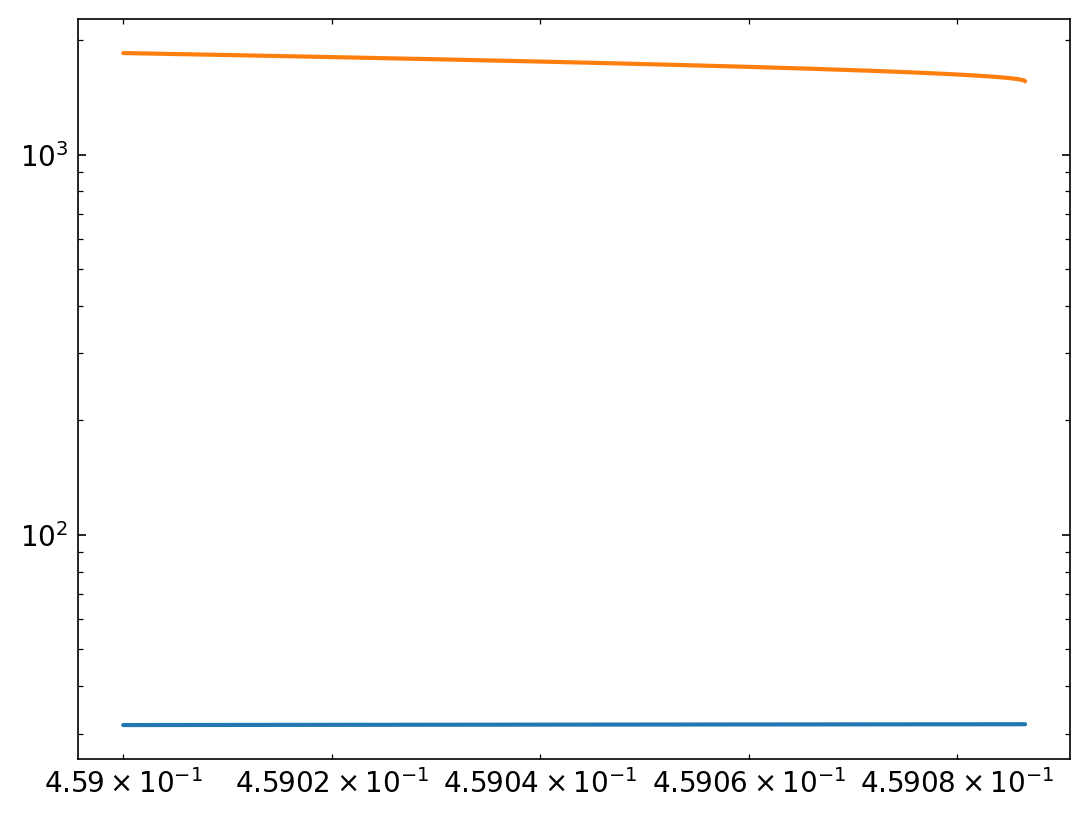

In [76]:
# plt.loglog(r/kpc, np.sqrt(P_wind/rho_wind)/km)
# plt.loglog(r/kpc, M_cloud/Msun)
plt.loglog(r/kpc, v_cloud/1e5)
plt.loglog(r/kpc, v_wind/1e5)

In [90]:
sol.status

1